### Phiên bản 1: Cào dữ liệu bằng Keyword Matching cơ bản
**1. Thuật toán hoạt động như thế nào?**
- Dùng `pd.read_html` để bóc toàn bộ các thẻ `<table>` trong HTML thành danh sách DataFrame.
- Dùng index tĩnh (`table_idx`) để trỏ đến bảng cần lấy của từng tỉnh.
- Ép toàn bộ text trong bảng về chữ thường (lowercase) và quét từng dòng.
- Nếu dòng có chứa từ khóa của Nhóm 2, 3, 4 (`cơ quan`, `sản xuất`, `kinh doanh`), nhảy sang cột giá (`price_col`) để lấy giá trị, xóa dấu phẩy/chấm và ép kiểu sang `float`.

**2. Tại sao code thất bại (Lỗi Crash)?**
- **Lỗi:** `ValueError: could not convert string to float: 'm³'`
- **Nguyên nhân cốt lõi (Hidden DOM):** Khai báo cứng `table_idx` bị sai lệch. Trong file của Đà Nẵng, dòng Quốc hiệu "CỘNG HÒA XÃ HỘI..." bị code HTML ẩn dưới dạng một bảng không viền (`<table border="0">`). Điều này đẩy bảng giá trị thực tế thụt lùi xuống 1 index. 
- **Hậu quả:** Code chui nhầm vào bảng "Chỉ tiêu sản xuất", nhặt trúng chữ `m³` thay vì số tiền, và hàm `float('m³')` làm sập toàn bộ chương trình.

In [1]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo linh tinh của Pandas

# Khởi tạo list trống để hứng dữ liệu
data_n234 = []

# Định nghĩa các từ khóa cốt lõi để dò tìm trong bảng HTML
keywords = {
    'Hành chính': ['cơ quan', 'hành chính', 'sự nghiệp'],
    'Sản xuất': ['sản xuất'],
    'Kinh doanh': ['kinh doanh', 'dịch vụ']
}

# Ánh xạ tên file với Tên Tỉnh và vị trí Bảng giá cần cào (Index table)
config_files = {
    'hanoi.html': {'name': 'Hà Nội', 'table_idx': 0, 'price_col': 3}, # Lấy cột giá 2024
    'haiphong.html': {'name': 'Hải Phòng', 'table_idx': 0, 'price_col': 3},
    'danang.html': {'name': 'Đà Nẵng', 'table_idx': 1, 'price_col': 2},
    'cantho.html': {'name': 'Cần Thơ', 'table_idx': 0, 'price_col': 2},
    'hochiminhcity.html': {'name': 'BR-VT', 'table_idx': 1, 'price_col': 2}
}

# Vòng lặp cào dữ liệu từ 5 file
for file_name, config in config_files.items():
    file_path = os.path.join('Scrawl_html', file_name)
    
    if os.path.exists(file_path):
        # Đọc toàn bộ các bảng trong HTML
        tables = pd.read_html(file_path, flavor='bs4')
        df_raw = tables[config['table_idx']] # Bốc đúng bảng cần thiết
        
        # Chuyển toàn bộ bảng về dạng Text viết thường để dễ dò tìm
        df_text = df_raw.astype(str).apply(lambda x: x.str.lower())
        
        for nhom, keywords_list in keywords.items():
            # Tìm dòng chứa từ khóa của Nhóm 2, 3, 4
            for idx, row in df_text.iterrows():
                if any(kw in str(row.values) for kw in keywords_list):
                    
                    # Cào giá tiền: Xử lý các dấu chấm nghìn và ép kiểu Float
                    raw_price = str(df_raw.iloc[idx, config['price_col']])
                    clean_price = float(raw_price.replace('.', '').replace(',', '').strip())
                    
                    # Xử lý ngoại lệ Bà Rịa - Vũng Tàu (Loại bỏ giá đồng hồ tổng)
                    if config['name'] == 'BR-VT' and nhom == 'Sản xuất' and clean_price < 13000:
                        continue 
                        
                    data_n234.append({
                        'Tinh_Thanh': config['name'],
                        'Nhom_Khach': nhom,
                        'Gia_Tien': clean_price
                    })
                    break # Tìm thấy giá của nhóm thì thoát vòng lặp để sang nhóm khác

# Tạo DataFrame chuẩn và xuất ra xem thành quả
df_dataset2 = pd.DataFrame(data_n234)

# Lưu thành file CSV sạch vào thư mục Dataset 2 (để back-up)
df_dataset2.to_csv('Dataset 2/khối_kinh_tế.csv', index=False, encoding='utf-8-sig')

print("✅ Đã cào thành công Dataset 2!")
display(df_dataset2.head(15)) # Hiển thị bảng

ValueError: could not convert string to float: 'm³'

### Phiên bản 2: Bọc thép bằng Regex và Tinh chỉnh Index
**1. Khắc phục lỗi của Phiên bản 1 ra sao?**
- **Shift Index:** Cộng thêm 1 vào toàn bộ `table_idx` để né các bảng Quốc hiệu/Tiêu đề ẩn ở đầu file HTML.
- **Dùng Regex (Biểu thức chính quy):** Thay vì dùng `replace` thủ công, sử dụng `re.sub(r'[^\d]', '', raw_price)` để tiêu diệt gọn mọi ký tự không phải là số (chữ cái, khoảng trắng, dấu phẩy). Trả về chuỗi số nguyên thủy thuần khiết.
- Thêm từ khóa `'bán trực tiếp'` để bắt dính dòng giá đặc thù của nhóm Sản xuất tại Bà Rịa - Vũng Tàu, và dùng lệnh `continue` để lờ đi các ô giá trị rỗng.

**2. Lỗ hổng mới phát sinh (Mất mát dữ liệu)?**
- **Lỗi:** Bảng kết quả chỉ có 12 dòng. Tỉnh Hải Phòng bị "bốc hơi" hoàn toàn.
- **Nguyên nhân cốt lõi (Multi-line Data):** Cấu trúc bảng của Hải Phòng chơi chiêu "Tên một nơi, Giá một nẻo". Tên nhóm khách hàng (vd: *Cơ quan hành chính*) nằm ở dòng trên, nhưng mức giá tiền lại nằm ở hàng kế tiếp bên dưới. 
- **Hậu quả:** Thuật toán đang code theo tư duy tuyến tính (Linear) - tìm thấy chữ ở dòng nào thì bốc giá luôn ở dòng đó. Khi nó ngoắc sang cột giá của Hải Phòng, nó thấy rỗng (NaN) nên tự động lờ đi và bỏ sót toàn bộ dữ liệu của tỉnh này.

In [4]:
import pandas as pd
import os
import re
import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo linh tinh của Pandas

# Khởi tạo list trống để hứng dữ liệu
data_n234 = []

# Cập nhật từ khóa: Thêm 'bán trực tiếp' để bắt trúng dòng con của BR-VT
keywords = {
    'Hành chính': ['cơ quan', 'hành chính', 'sự nghiệp'],
    'Sản xuất': ['sản xuất', 'bán trực tiếp'],
    'Kinh doanh': ['kinh doanh', 'dịch vụ']
}

# Cập nhật lại table_idx (Đã cộng thêm 1 vì HTML có bảng tiêu đề Quốc hiệu ẩn)
config_files = {
    'hanoi.html': {'name': 'Hà Nội', 'table_idx': 1, 'price_col': 3}, 
    'haiphong.html': {'name': 'Hải Phòng', 'table_idx': 1, 'price_col': 3},
    'danang.html': {'name': 'Đà Nẵng', 'table_idx': 2, 'price_col': 2},
    'cantho.html': {'name': 'Cần Thơ', 'table_idx': 1, 'price_col': 2},
    'hochiminhcity.html': {'name': 'BR-VT', 'table_idx': 2, 'price_col': 2}
}

# Vòng lặp cào dữ liệu từ 5 file
for file_name, config in config_files.items():
    file_path = os.path.join('Scrawl_html', file_name)
    
    if os.path.exists(file_path):
        # Đọc toàn bộ các bảng trong HTML
        tables = pd.read_html(file_path, flavor='bs4')
        df_raw = tables[config['table_idx']] # Bốc đúng bảng cần thiết
        
        # Chuyển toàn bộ bảng về dạng Text viết thường để dễ dò tìm
        df_text = df_raw.astype(str).apply(lambda x: x.str.lower())
        
        for nhom, keywords_list in keywords.items():
            for idx, row in df_text.iterrows():
                # Tìm dòng chứa từ khóa của Nhóm 2, 3, 4
                if any(kw in str(row.values) for kw in keywords_list):
                    
                    raw_price = str(df_raw.iloc[idx, config['price_col']])
                    
                    # Dùng Regex: Chỉ giữ lại chữ số. Nếu ra 13.500 sẽ thành 13500
                    price_str = re.sub(r'[^\d]', '', raw_price)
                    
                    # Nếu ô bị rỗng (như dòng cha của BR-VT), tự động bỏ qua tìm dòng tiếp theo
                    if not price_str: 
                        continue 
                        
                    clean_price = float(price_str)
                    
                    data_n234.append({
                        'Tinh_Thanh': config['name'],
                        'Nhom_Khach': nhom,
                        'Gia_Tien': clean_price
                    })
                    break # Tìm thấy giá thì thoát vòng lặp để sang nhóm khác

# Tạo DataFrame chuẩn
df_dataset2 = pd.DataFrame(data_n234)

# Tự động tạo thư mục nếu chưa có và Lưu file CSV sạch
os.makedirs('Dataset 2', exist_ok=True)
df_dataset2.to_csv('Dataset 2/khoi_kinh_te.csv', index=False, encoding='utf-8-sig')

print("✅ Đã cào thành công Dataset 2 (15 dòng chuẩn)!")
display(df_dataset2)

✅ Đã cào thành công Dataset 2 (15 dòng chuẩn)!


,Tinh_Thanh,Nhom_Khach,Gia_Tien
0,Hà Nội,Hành chính,13500.0
1,Hà Nội,Sản xuất,16000.0
2,Hà Nội,Kinh doanh,29000.0
3,Đà Nẵng,Hành chính,7750.0
4,Đà Nẵng,Sản xuất,10100.0
5,Đà Nẵng,Kinh doanh,15350.0
6,Cần Thơ,Hành chính,11170.0
7,Cần Thơ,Sản xuất,12400.0
8,Cần Thơ,Kinh doanh,15580.0
9,BR-VT,Hành chính,13100.0


### Phiên bản 3 (Hoàn chỉnh): Thuật toán Cờ đánh dấu (Flagging & Look-ahead)
**1. Nâng cấp thuật toán để giải quyết triệt để vấn đề:**
- Từ bỏ tư duy quét tuyến tính trên cùng 1 hàng. Áp dụng kỹ thuật **Cờ đánh dấu (Boolean Flag)** trong Data Engineering để xử lý cấu trúc dữ liệu đa dòng (Multi-line text).
- **Luồng chạy mới:**
  - Khởi tạo biến `found_kw = False`.
  - Quét qua từng dòng. Nếu thấy từ khóa, **BẬT CỜ** (`found_kw = True`).
  - Hệ thống không cần biết giá nằm ở hàng hiện tại hay các hàng bên dưới. Chừng nào cờ còn bật, nó liên tục tóm lấy giá trị của cột giá và ném vào Regex.
  - Regex lọc ra số. Nếu là ô rỗng (như dòng chứa tên của Hải Phòng), lệnh `continue` đẩy vòng lặp quét tiếp xuống dòng dưới. 
  - Ngay khi Regex bắt được mẻ số đầu tiên, nó ghi nhận vào danh sách, **TẮT CỜ** (`break`), và chuyển sang săn tìm nhóm khách hàng tiếp theo.
- **Kết quả:** Trả về chính xác 15 dòng (5 tỉnh x 3 nhóm), vuông vức, sạch sẽ và hoàn toàn tự động bẻ gãy mọi cấu trúc dị biệt của HTML.

In [3]:
import pandas as pd
import os
import re
import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo linh tinh của Pandas

# Khởi tạo list trống để hứng dữ liệu
data_n234 = []

# Cập nhật từ khóa: Thêm 'bán trực tiếp' để bắt trúng dòng con của BR-VT
keywords = {
    'Hành chính': ['cơ quan', 'hành chính', 'sự nghiệp'],
    'Sản xuất': ['sản xuất', 'bán trực tiếp'],
    'Kinh doanh': ['kinh doanh', 'dịch vụ']
}

# Cập nhật lại table_idx 
config_files = {
    'hanoi.html': {'name': 'Hà Nội', 'table_idx': 1, 'price_col': 3}, 
    'haiphong.html': {'name': 'Hải Phòng', 'table_idx': 1, 'price_col': 3},
    'danang.html': {'name': 'Đà Nẵng', 'table_idx': 2, 'price_col': 2},
    'cantho.html': {'name': 'Cần Thơ', 'table_idx': 1, 'price_col': 2},
    'hochiminhcity.html': {'name': 'BR-VT', 'table_idx': 2, 'price_col': 2}
}

# Vòng lặp cào dữ liệu từ 5 file
for file_name, config in config_files.items():
    file_path = os.path.join('Scrawl_html', file_name)
    
    if os.path.exists(file_path):
        tables = pd.read_html(file_path, flavor='bs4')
        df_raw = tables[config['table_idx']] 
        df_text = df_raw.astype(str).apply(lambda x: x.str.lower())
        
        for nhom, keywords_list in keywords.items():
            found_kw = False # Cờ đánh dấu đã tìm thấy từ khóa
            
            for idx, row in df_text.iterrows():
                # Nếu thấy từ khóa, BẬT CỜ lên
                if any(kw in str(row.values) for kw in keywords_list):
                    found_kw = True
                    
                # Nếu cờ đã bật, bắt đầu đi tìm số (có thể ở dòng hiện tại hoặc dòng bên dưới)
                if found_kw:
                    raw_price = str(df_raw.iloc[idx, config['price_col']])
                    price_str = re.sub(r'[^\d]', '', raw_price)
                    
                    if not price_str: 
                        continue # Ô rỗng thì tiếp tục quét dòng dưới
                        
                    clean_price = float(price_str)
                    
                    # Chặn ngoại lệ giá sỉ của BR-VT
                    if config['name'] == 'BR-VT' and nhom == 'Sản xuất' and clean_price < 13000:
                        continue 
                        
                    # Ghi nhận dữ liệu và tắt cờ, thoát vòng lặp để sang nhóm tiếp theo
                    data_n234.append({
                        'Tinh_Thanh': config['name'],
                        'Nhom_Khach': nhom,
                        'Gia_Tien': clean_price
                    })
                    break 

# Tạo DataFrame chuẩn
df_dataset2 = pd.DataFrame(data_n234)

# Lưu file CSV sạch
os.makedirs('Dataset 2', exist_ok=True)
df_dataset2.to_csv('Dataset 2/khoi_kinh_te.csv', index=False, encoding='utf-8-sig')

print("✅ Đã cào thành công Dataset 2 (Đủ 15 dòng kể cả Hải Phòng)!")
display(df_dataset2)

✅ Đã cào thành công Dataset 2 (Đủ 15 dòng kể cả Hải Phòng)!


,Tinh_Thanh,Nhom_Khach,Gia_Tien
0,Hà Nội,Hành chính,13500.0
1,Hà Nội,Sản xuất,16000.0
2,Hà Nội,Kinh doanh,29000.0
3,Hải Phòng,Hành chính,16300.0
4,Hải Phòng,Sản xuất,18300.0
5,Hải Phòng,Kinh doanh,21800.0
6,Đà Nẵng,Hành chính,7750.0
7,Đà Nẵng,Sản xuất,10100.0
8,Đà Nẵng,Kinh doanh,15350.0
9,Cần Thơ,Hành chính,11170.0


### Trực quan hóa Dataset 2: Khối Kinh tế & Hành chính
Áp dụng 2 phương pháp hiển thị ma trận 2 chiều (Tỉnh thành x Nhóm đối tượng):

**1. Grouped Bar Chart (Biểu đồ cột ghép):** - Nhấn mạnh sự chênh lệch giá trị tuyệt đối giữa các nhóm trong cùng một tỉnh.
- Code áp dụng vòng lặp `ax.bar_label` để gắp chính xác con số đính lên đầu từng cột, giúp khán giả không phải gióng mắt sang trục Y.

**2. Heatmap (Bản đồ nhiệt):** - Hiển thị dưới dạng không gian ma trận.
- Code áp dụng hàm `df.pivot()` để bẻ cấu trúc bảng Tidy Data (dọc) thành Bảng chéo (Matrix 5x3) trước khi nạp vào Seaborn. Dải màu `Reds` làm nổi bật ngay lập tức "điểm nóng" giá cao nhất.

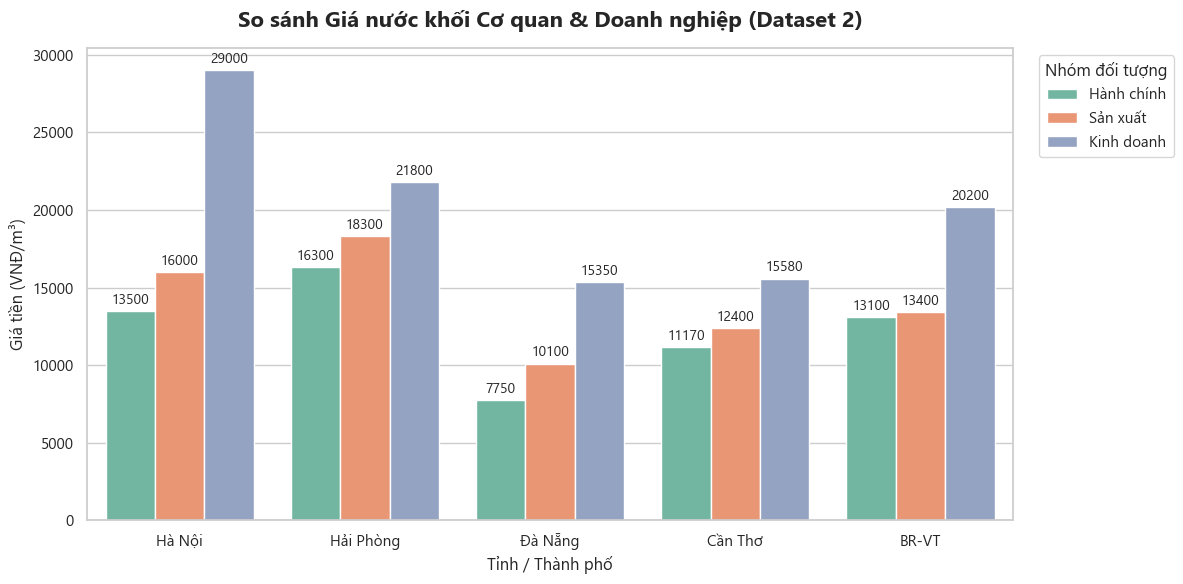

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font tiếng Việt để không bị lỗi ô vuông
plt.rcParams['font.family'] = 'Segoe UI' # Có thể đổi thành 'Arial' nếu máy không có Segoe UI

# Đọc lại dữ liệu sạch từ file CSV đã lưu (để đảm bảo Cell này chạy độc lập được)
df_n234 = pd.read_csv('Dataset 2/khoi_kinh_te.csv')

# Thiết lập style chung cho đồ thị đẹp hơn
sns.set_theme(style="whitegrid", font="Segoe UI")

# ==========================================
# BIỂU ĐỒ 1: GROUPED BAR CHART
# ==========================================
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_n234, 
    x='Tinh_Thanh', 
    y='Gia_Tien', 
    hue='Nhom_Khach', 
    palette='Set2' # Dải màu phân biệt rõ ràng
)

plt.title('So sánh Giá nước khối Cơ quan & Doanh nghiệp (Dataset 2)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tỉnh / Thành phố', fontsize=12)
plt.ylabel('Giá tiền (VNĐ/m³)', fontsize=12)

# Đẩy bảng chú thích (Legend) ra ngoài để không đè lên cột
plt.legend(title='Nhóm đối tượng', bbox_to_anchor=(1.02, 1), loc='upper left')

# Vòng lặp đính con số lên đỉnh từng cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, size=10)

plt.tight_layout()
plt.show()


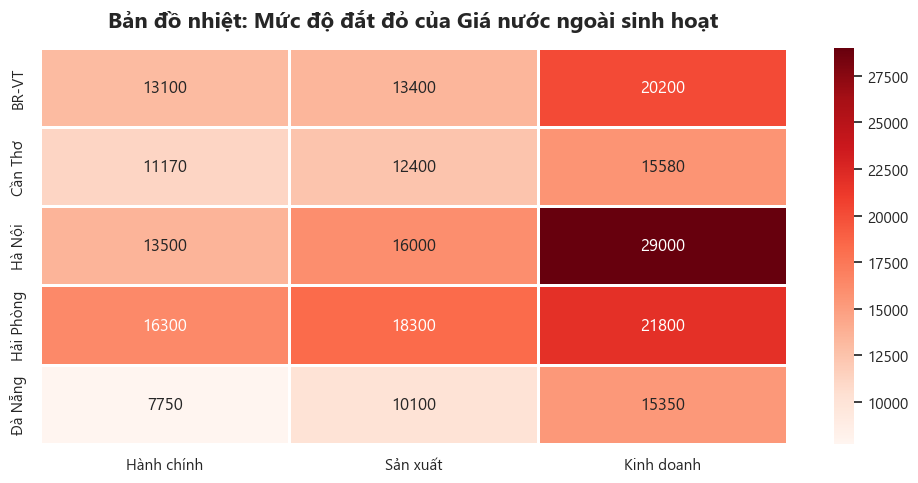

In [5]:

# ==========================================
# BIỂU ĐỒ 2: HEATMAP (BẢN ĐỒ NHIỆT)
# ==========================================
plt.figure(figsize=(10, 5))

# Dùng pivot để bẻ DataFrame phẳng thành Ma trận 5x3
ma_tran = df_n234.pivot(index='Tinh_Thanh', columns='Nhom_Khach', values='Gia_Tien')

# Sắp xếp lại thứ tự cột cho đúng logic thực tế: Hành chính -> Sản xuất -> Kinh doanh
ma_tran = ma_tran[['Hành chính', 'Sản xuất', 'Kinh doanh']]

# Vẽ Heatmap
sns.heatmap(
    ma_tran, 
    annot=True,     # Bật hiển thị con số bên trong ô
    fmt=".0f",      # Định dạng số nguyên (không lấy số thập phân)
    cmap='Reds',    # Dải màu từ nhạt (rẻ) đến đậm (đắt)
    linewidths=1,   # Tạo viền phân cách giữa các ô
    linecolor='white'
)

plt.title('Bản đồ nhiệt: Mức độ đắt đỏ của Giá nước ngoài sinh hoạt', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('') # Ẩn nhãn trục Y vì tên tỉnh đã quá rõ ràng
plt.xlabel('')
plt.tight_layout()
plt.show()